# Elencos e estatísticas individuais — FBref

Este notebook parte da **raspagem da FBref** (`src/fbref_scraper.py`) e mostra
como transformar o dado bruto em índices de elenco que alimentam o modelo.

Fonte: [FBref Copa Libertadores](https://fbref.com/en/comps/14/stats/Copa-Libertadores-Stats)
(snapshot em `data/historical/fbref/elencos_2026.csv`, coletado em 22/08/2026).

> A FBref **não publica** passing/xG/defense avançados para a Libertadores.
> Usamos o que existe de verdade: Standard + Shooting + Miscellaneous
> (gols, assistências, finalizações, desarmes ganhos, interceptações, faltas).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from src.fbref_scraper import load_elencos, load_jogadores
from src.fbref_features import indices_completos, confronto_indices

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)

elencos = load_elencos()
elencos[['time', 'jogos', 'gols', 'assistencias', 'finalizacoes_no_gol', 'desarmes_ganhos', 'interceptacoes']].head()

,time,jogos,gols,assistencias,finalizacoes_no_gol,desarmes_ganhos,interceptacoes
0,Always Ready,6,7,7,33,64,64
1,Barcelona SC,6,2,2,16,45,50
2,Boca Juniors,6,6,5,31,49,52
3,Bolívar,6,6,4,28,74,37
4,Cerro Porteño,8,5,3,21,112,90


## 1. Índices de força ofensiva e pressão defensiva

Não jogamos médias cruas no modelo. Agregamos:

* **Força ofensiva** = `0.4·gols/90 + 0.3·assist/90 + 0.2·SoT/90 + 0.1·chutes/90`
* **Pressão defensiva** = `(desarmes ganhos + interceptações) / 90`
* **Disciplina** = `(cartões + faltas) / 90` (menor é mais limpo)

In [2]:
idx = indices_completos(elencos, load_jogadores())
cols = ['time', 'indice_forca_ofensiva', 'indice_pressao_defensiva', 'indice_disciplina', 'gols_sofridos_90']
idx[cols].sort_values('indice_forca_ofensiva', ascending=False).head(10)

,time,indice_forca_ofensiva,indice_pressao_defensiva,indice_disciplina,gols_sofridos_90
16,Independiente del Valle,4.313714,16.571429,8.142857,0.857143
12,Flamengo,4.124500,15.125000,8.375000,0.500000
23,Palmeiras,3.913000,17.750000,11.625000,0.500000
0,Always Ready,3.549667,21.333333,14.666667,1.500000
11,Estudiantes,3.225000,18.000000,14.750000,0.750000
15,Independiente Rivadavia,3.172482,17.469880,14.578313,0.843373
26,Rosario Central,3.125000,19.250000,14.000000,0.250000
2,Boca Juniors,3.117000,16.833333,14.166667,0.833333
28,Sporting Cristal,2.883000,17.166667,13.500000,1.500000
3,Bolívar,2.867000,18.500000,11.166667,1.166667


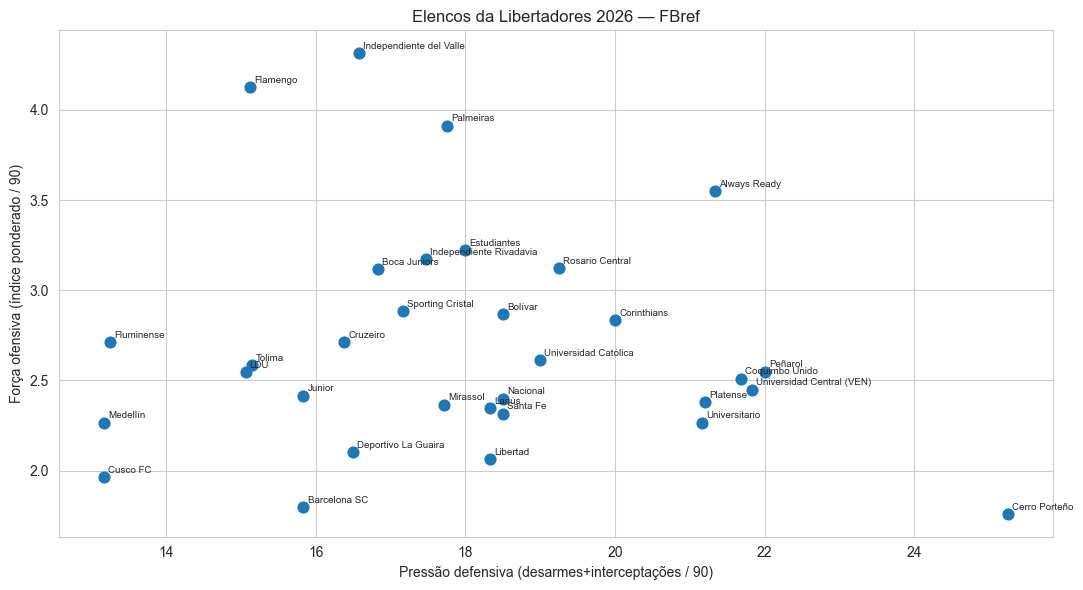

In [3]:
plot = idx.sort_values('indice_forca_ofensiva')
fig, ax = plt.subplots()
ax.scatter(plot['indice_pressao_defensiva'], plot['indice_forca_ofensiva'], s=60)
for _, r in plot.iterrows():
    ax.annotate(r['time'], (r['indice_pressao_defensiva'], r['indice_forca_ofensiva']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Pressão defensiva (desarmes+interceptações / 90)')
ax.set_ylabel('Força ofensiva (índice ponderado / 90)')
ax.set_title('Elencos da Libertadores 2026 — FBref')
plt.tight_layout()
plt.show()

## 2. Confrontos das quartas em cima dos índices

Diferença mandante − visitante: positivo favorece o mandante.

In [4]:
confrontos = [
    ('Fluminense', 'Platense'),
    ('Estudiantes', 'Corinthians'),
    ('Palmeiras', 'LDU'),
    ('Flamengo', 'Tolima'),
]
linhas = [confronto_indices(idx, a, b).iloc[0] for a, b in confrontos]
pd.DataFrame(linhas)[['mandante', 'visitante', 'diff_indice_forca_ofensiva', 'diff_indice_pressao_defensiva']]

,mandante,visitante,diff_indice_forca_ofensiva,diff_indice_pressao_defensiva
0,Fluminense,Platense,0.335518,-7.951807
0,Estudiantes,Corinthians,0.388000,-2.000000
0,Palmeiras,LDU,1.366590,2.689759
0,Flamengo,Tolima,1.538929,-0.017857


## 3. Como atualizar a raspagem

```bash
python src/fbref_scraper.py scrape --season 2026
```

O cliente espera 3,5 s entre GET (política da Sports-Reference), cacheia o HTML
em `data/raw/fbref/` e grava CSV + SQLite em `data/processed/`.
Sem rede, o pipeline cai automaticamente neste snapshot.